# Analysis of chunking with PIRB results
This notebook parses a file with PIRB results: `results_*.txt` and session run files: `session_*/run_*/metadata.json`, aggregates metrics per dataset and method, and produces visualizations.

In [ ]:
import json
from pathlib import Path
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

### Set a session dir

In [186]:
session_path = Path.cwd() / 'sessions/session2'

## Read results_*.txt

In [187]:
root = Path(session_path)
results_paths = list(root.rglob('results_*.txt'))
if not results_paths:
    logging.warning('results_*.txt not found in workspace root or subfolders.')
records = []
for p in results_paths:
    print(f'Reading {p.relative_to(Path.cwd())}...')
    with open(p, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                records.append(obj)
            except Exception as e:
                logging.warning(f'Line {i+1} in {p} is not valid JSON: {e}')
# Quick preview
len(records)

if records:
    df = pd.json_normalize(records)
    df.rename(columns=lambda c: c.replace('@','@').replace('metrics.',''), inplace=True)
    df[[f"Accuracy@{i}" for i in range(2, 6)]] = pd.DataFrame(
        df["Accuracy@1-5"].apply(lambda x: x[1:]).tolist(),
        index=df.index
    ) 
else:
    df = pd.DataFrame()

print(f"Number of runs: {len(df)}")
df.head().T

Reading sessions/session2/results_all.txt...
Number of runs: 55


,0,1,2,3,4
task_id,run_0001,run_0002,run_0003,run_0004,run_0005
group_id,BEIR-PL,BEIR-PL,BEIR-PL,BEIR-PL,BEIR-PL
model,dense_BAAI_bge-m3,dense_BAAI_bge-m3,dense_BAAI_bge-m3,dense_BAAI_bge-m3,dense_BAAI_bge-m3
timestamp,"21/03/2026,15:23:34","21/03/2026,15:23:17","21/03/2026,15:20:21","21/03/2026,15:19:14","21/03/2026,15:19:53"
Accuracy@1,59.409594,58.839316,78.305085,90.0,92.666667
Accuracy@1-5,"[59.40959409594096, 69.40623951694063, 74.6393...","[58.83931566588393, 70.04360952700436, 74.9748...","[78.30508474576271, 82.11864406779661, 84.2372...","[90.0, 96.0, 96.0, 98.0, 99.0]","[92.66666666666667, 96.0, 97.33333333333333, 9..."
Recall@10,36.398088,33.73882,1.544818,17.292466,17.378081
MRR@10,68.342865,68.201932,81.610203,93.8,95.227778
NDCG@10,38.926699,37.330381,73.987362,81.091481,84.515834
metadata.name,BAAI/bge-m3,BAAI/bge-m3,BAAI/bge-m3,BAAI/bge-m3,BAAI/bge-m3


## Discover and load session_*/run_*/metadata.json files

In [188]:
meta_records = []
for meta_path in root.rglob('session_*/*/metadata.json'):
    try:
        with open(meta_path, 'r', encoding='utf-8') as f:
            m = json.load(f)
        run_id = meta_path.parent.name
        session_id = meta_path.parents[1].name if len(meta_path.parents) > 1 else ''
        entry = {'file_path': str(meta_path), 'run_id': run_id, 'session_id': session_id}
        # merge metadata fields (shallow)
        if isinstance(m, dict):
            for k,v in m.items():
                entry[f'meta_file.{k}'] = v
        meta_records.append(entry)
    except Exception as e:
        logging.warning(f'Failed to read {meta_path}: {e}')

meta_df = pd.DataFrame(meta_records)
meta_df[['chunker_init_seconds', 'chunking_seconds', 'total_runtime_seconds']] = meta_df['meta_file.timing'].apply(
    lambda x: pd.Series({
        'chunker_init_seconds': x.get('chunker_init_seconds'),
        'chunking_seconds': x.get('chunking_seconds'),
        'total_runtime_seconds': x.get('total_runtime_seconds')
    })
)
print(f"Number of runs: {len(meta_df)}")
meta_df.head().T

Number of runs: 55


,0,1,2,3,4
file_path,/home/mateusz/PhD/Chunking/Results/sessions/se...,/home/mateusz/PhD/Chunking/Results/sessions/se...,/home/mateusz/PhD/Chunking/Results/sessions/se...,/home/mateusz/PhD/Chunking/Results/sessions/se...,/home/mateusz/PhD/Chunking/Results/sessions/se...
run_id,run_0042,run_0049,run_0043,run_0087,run_0039
session_id,session_20260313T142157Z,session_20260313T142157Z,session_20260313T142157Z,session_20260313T142157Z,session_20260313T142157Z
meta_file.status,success,success,success,success,success
meta_file.run_number,42,49,43,87,39
meta_file.total_runs,172,172,172,172,172
meta_file.group_name,recursive_semantic_train_datasets,sequential_hac_train_datasets,recursive_semantic_train_datasets,lumberchunker_train_datasets,recursive_semantic_train_datasets
meta_file.dataset_slug,novelqa_public,gutenqa_all,poquad_train,literaryqa_validation,literaryqa_validation
meta_file.documents_source_path,data/processed/novelqa/public/documents/docume...,data/processed/gutenqa/all/documents/documents...,data/processed/poquad/train/documents/document...,data/processed/literaryqa/validation/documents...,data/processed/literaryqa/validation/documents...
meta_file.queries_source_path,data/processed/novelqa/public/queries/queries....,data/processed/gutenqa/all/queries/queries.jsonl,data/processed/poquad/train/queries/queries.jsonl,data/processed/literaryqa/validation/queries/q...,data/processed/literaryqa/validation/queries/q...


## Merge run results with per-run metadata

In [189]:
if not df.empty and not meta_df.empty:
    merged = df.copy()
    # normalize keys for merging
    if 'task_id' in merged.columns:
        merged = merged.merge(meta_df, left_on='task_id', right_on='run_id', how='left')
    else:
        # fallback: try match by model / meta_file.name
        if 'model' in merged.columns and 'meta_file.name' in meta_df.columns:
            merged = merged.merge(meta_df, left_on='model', right_on='meta_file.name', how='left')
        else:
            # cartesian join fallback (attach meta info as available)
            merged['merge_helper'] = 1
            if not meta_df.empty:
                tmp = meta_df.copy(); tmp['merge_helper'] = 1
                merged = merged.merge(tmp, on='merge_helper', how='left').drop(columns=['merge_helper'])
else:
    merged = df.copy()
# Create canonical columns
merged['dataset'] = merged.get('meta_file.dataset_slug')
merged['method'] = merged.get('meta_file.chunker_name', None)
merged['fp16'] = merged.get('meta.fp16', merged.get('meta_file.fp16', None))
merged['batch_size'] = merged.get('meta.batch_size', merged.get('meta_file.batch_size', None))
merged['max_seq_length'] = merged.get('meta.max_seq_length', merged.get('meta_file.max_seq_length', None))
print(f"Shape of merged DataFrame: {merged.shape}")
merged.head().T

Shape of merged DataFrame: (55, 58)


,0,1,2,3,4
task_id,run_0001,run_0002,run_0003,run_0004,run_0005
group_id,BEIR-PL,BEIR-PL,BEIR-PL,BEIR-PL,BEIR-PL
model,dense_BAAI_bge-m3,dense_BAAI_bge-m3,dense_BAAI_bge-m3,dense_BAAI_bge-m3,dense_BAAI_bge-m3
timestamp,"21/03/2026,15:23:34","21/03/2026,15:23:17","21/03/2026,15:20:21","21/03/2026,15:19:14","21/03/2026,15:19:53"
Accuracy@1,59.409594,58.839316,78.305085,90.0,92.666667
Accuracy@1-5,"[59.40959409594096, 69.40623951694063, 74.6393...","[58.83931566588393, 70.04360952700436, 74.9748...","[78.30508474576271, 82.11864406779661, 84.2372...","[90.0, 96.0, 96.0, 98.0, 99.0]","[92.66666666666667, 96.0, 97.33333333333333, 9..."
Recall@10,36.398088,33.73882,1.544818,17.292466,17.378081
MRR@10,68.342865,68.201932,81.610203,93.8,95.227778
NDCG@10,38.926699,37.330381,73.987362,81.091481,84.515834
metadata.name,BAAI/bge-m3,BAAI/bge-m3,BAAI/bge-m3,BAAI/bge-m3,BAAI/bge-m3


### Show missing data from runs in results

In [190]:
missing_in_merged = meta_df[~meta_df['run_id'].isin(merged['task_id'])]
missing_in_merged.T if missing_in_merged.shape[0] > 0 else print("All metadata runs are present in merged DataFrame.")

All metadata runs are present in merged DataFrame.


### Show number of runs per method

Number of runs: 55
Method: fixed_size, Runs: 10
Method: max_min_chunker, Runs: 9
Method: recursive_semantic, Runs: 11
Method: sequential_hac_chunker, Runs: 9
Method: text_tiling, Runs: 8
Method: graphseg, Runs: 6
Method: lumberchunker, Runs: 2


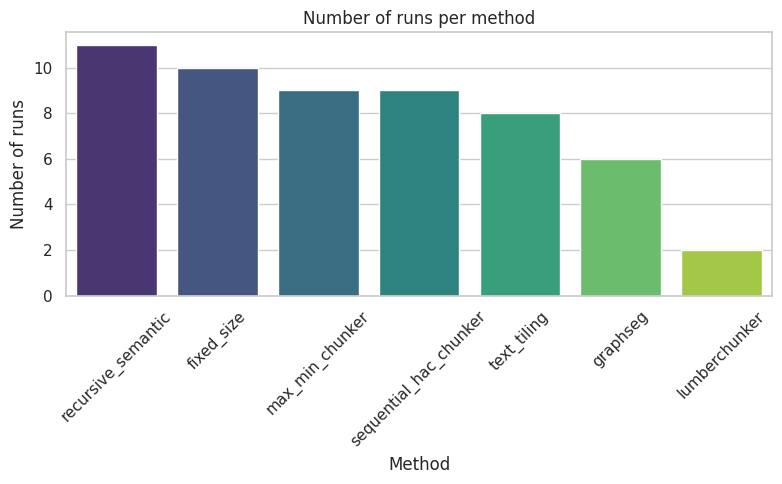

In [191]:
print(f"Number of runs: {len(merged)}")

for method in merged['method'].unique():
    subset = merged[merged['method'] == method]
    print(f"Method: {method}, Runs: {len(subset)}")

# Plot: number of runs per method
method_counts = merged['method'].value_counts().reset_index()
method_counts.columns = ['method', 'runs']
plt.figure(figsize=(8, 5))
sns.barplot(data=method_counts, x='method', y='runs', hue='method', palette='viridis', legend=False)
plt.xlabel('Method')
plt.ylabel('Number of runs')
plt.title('Number of runs per method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Metrics analysis

In [192]:
def plot_metric_by_method(metric, title=None):
    plt.figure(figsize=(18, 10))
    sns.barplot(
        data=merged,
        x='dataset',
        y=f"{metric}",
        hue='method',
        palette='viridis'
    )
    plt.xlabel('Dataset')
    plt.ylabel(metric)
    plt.title(title or f'{metric} by dataset and method')
    plt.xticks(rotation=90)
    plt.legend(title='Method')
    plt.tight_layout()
    plt.show()

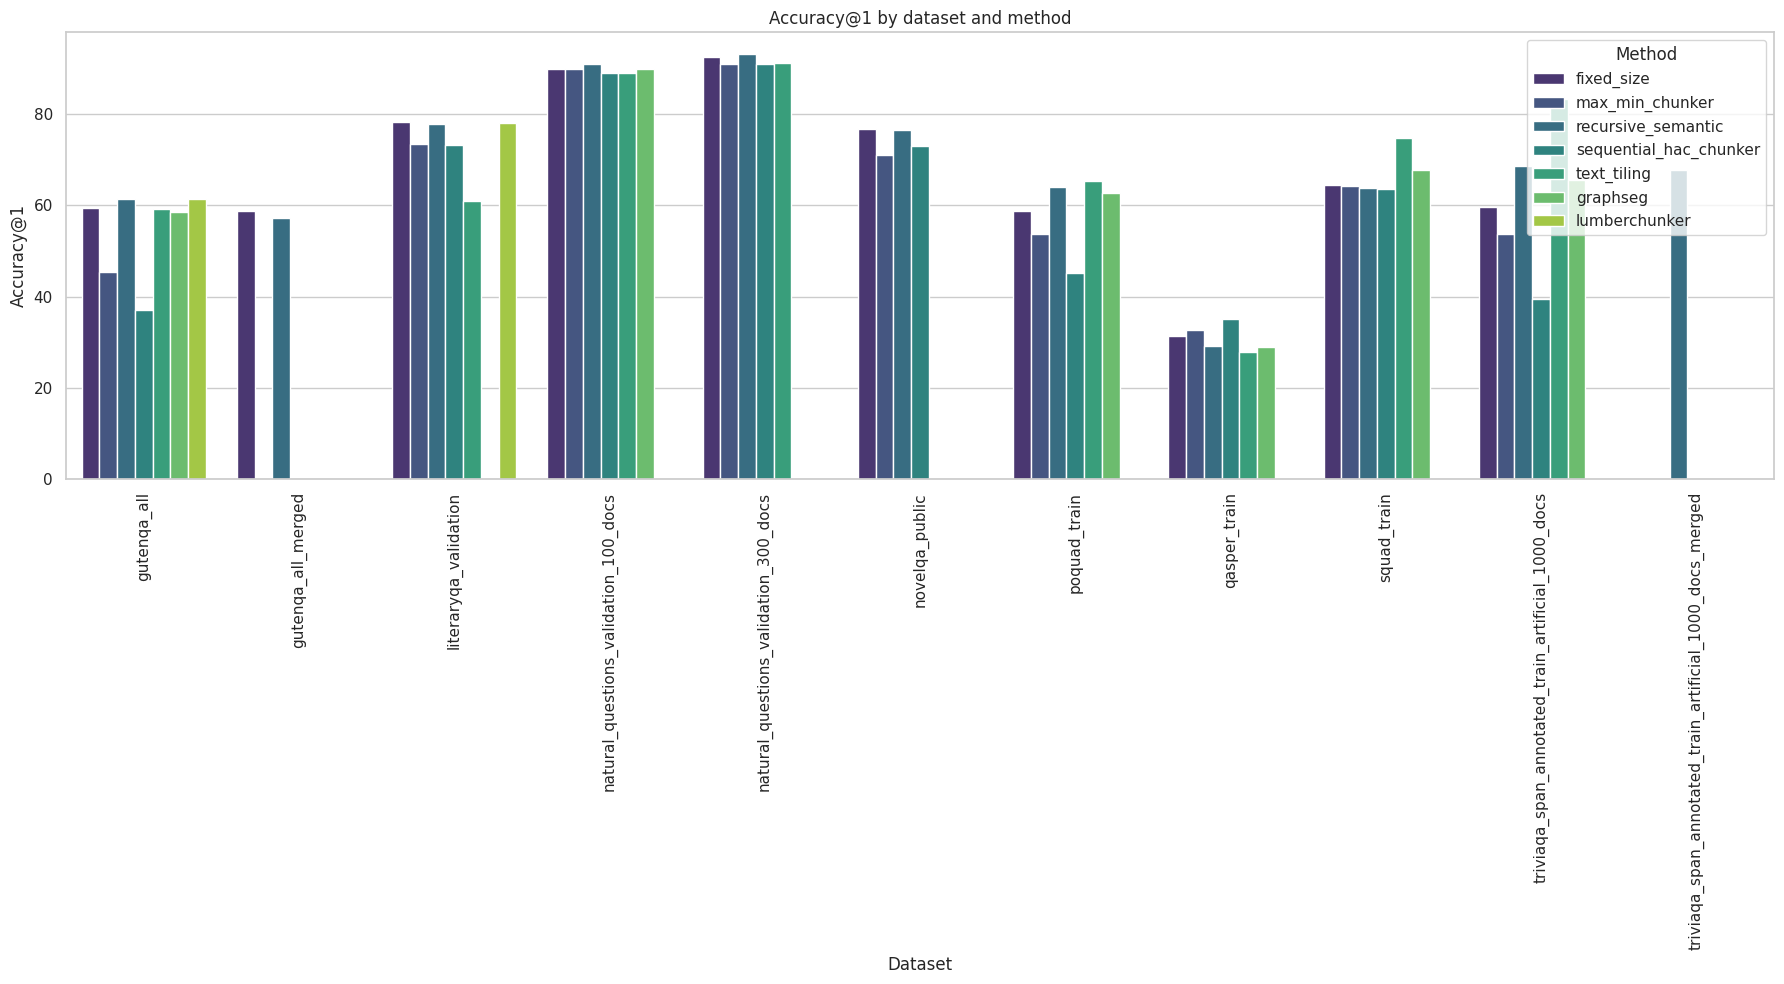

In [193]:
plot_metric_by_method('Accuracy@1')

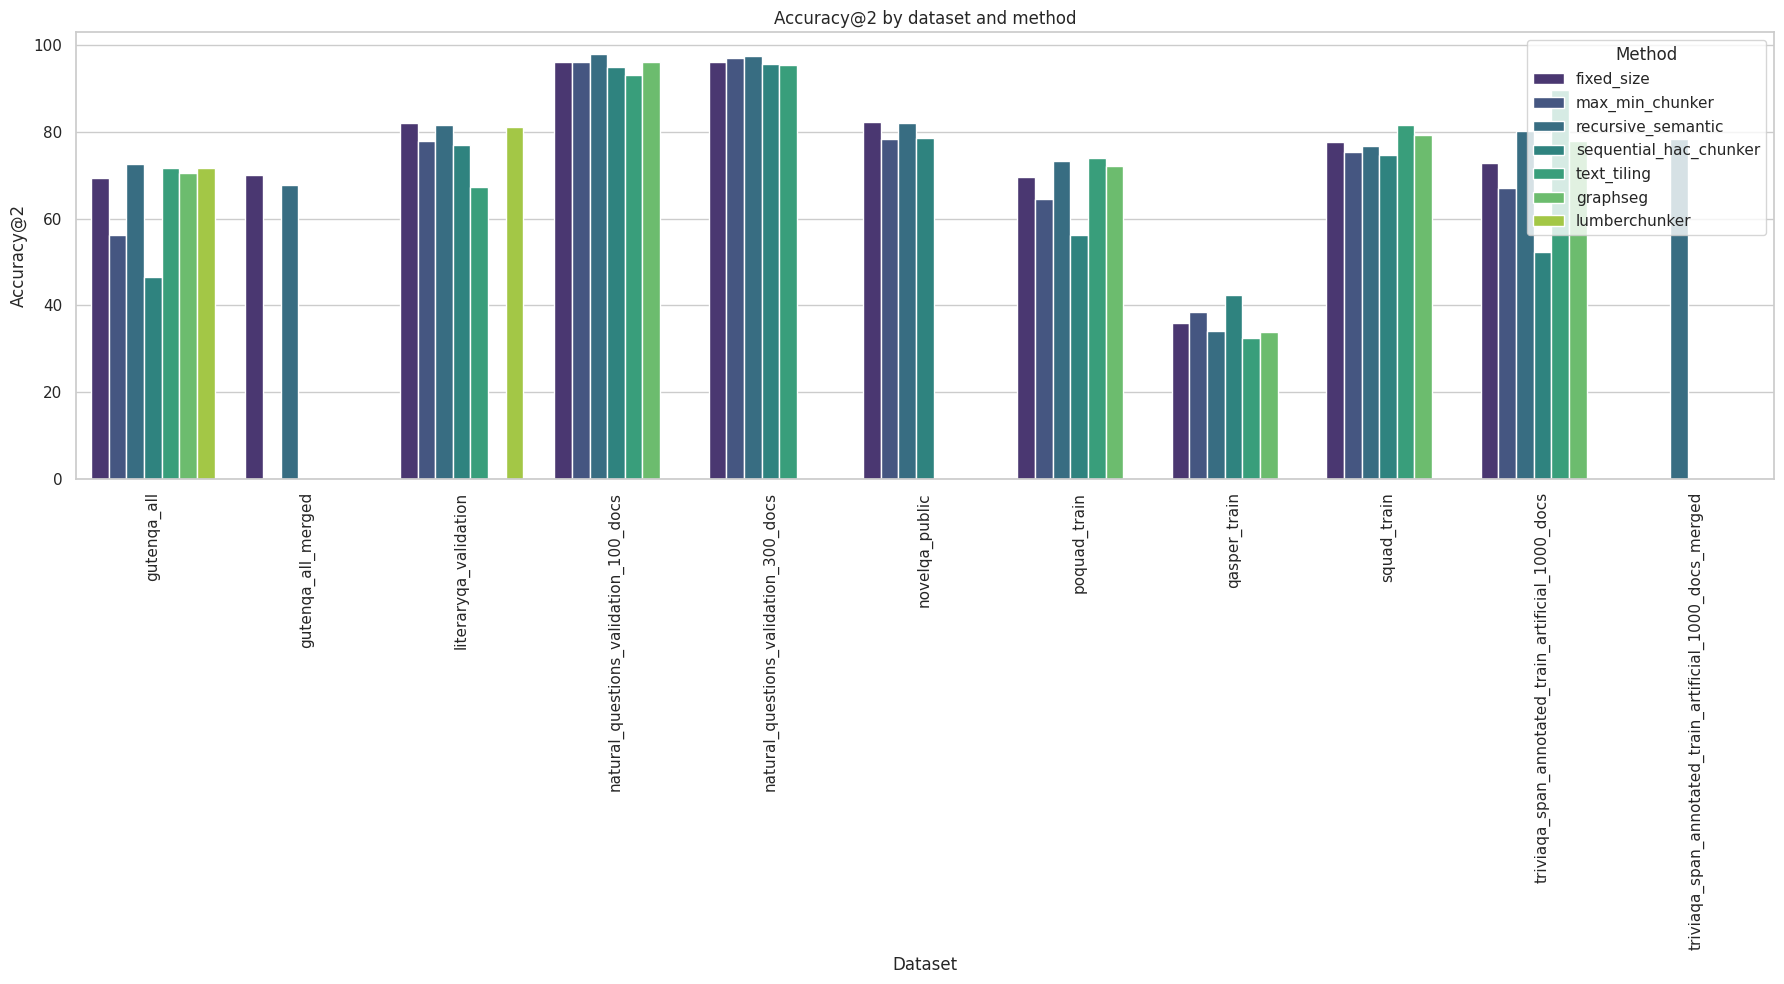

In [194]:
plot_metric_by_method('Accuracy@2')

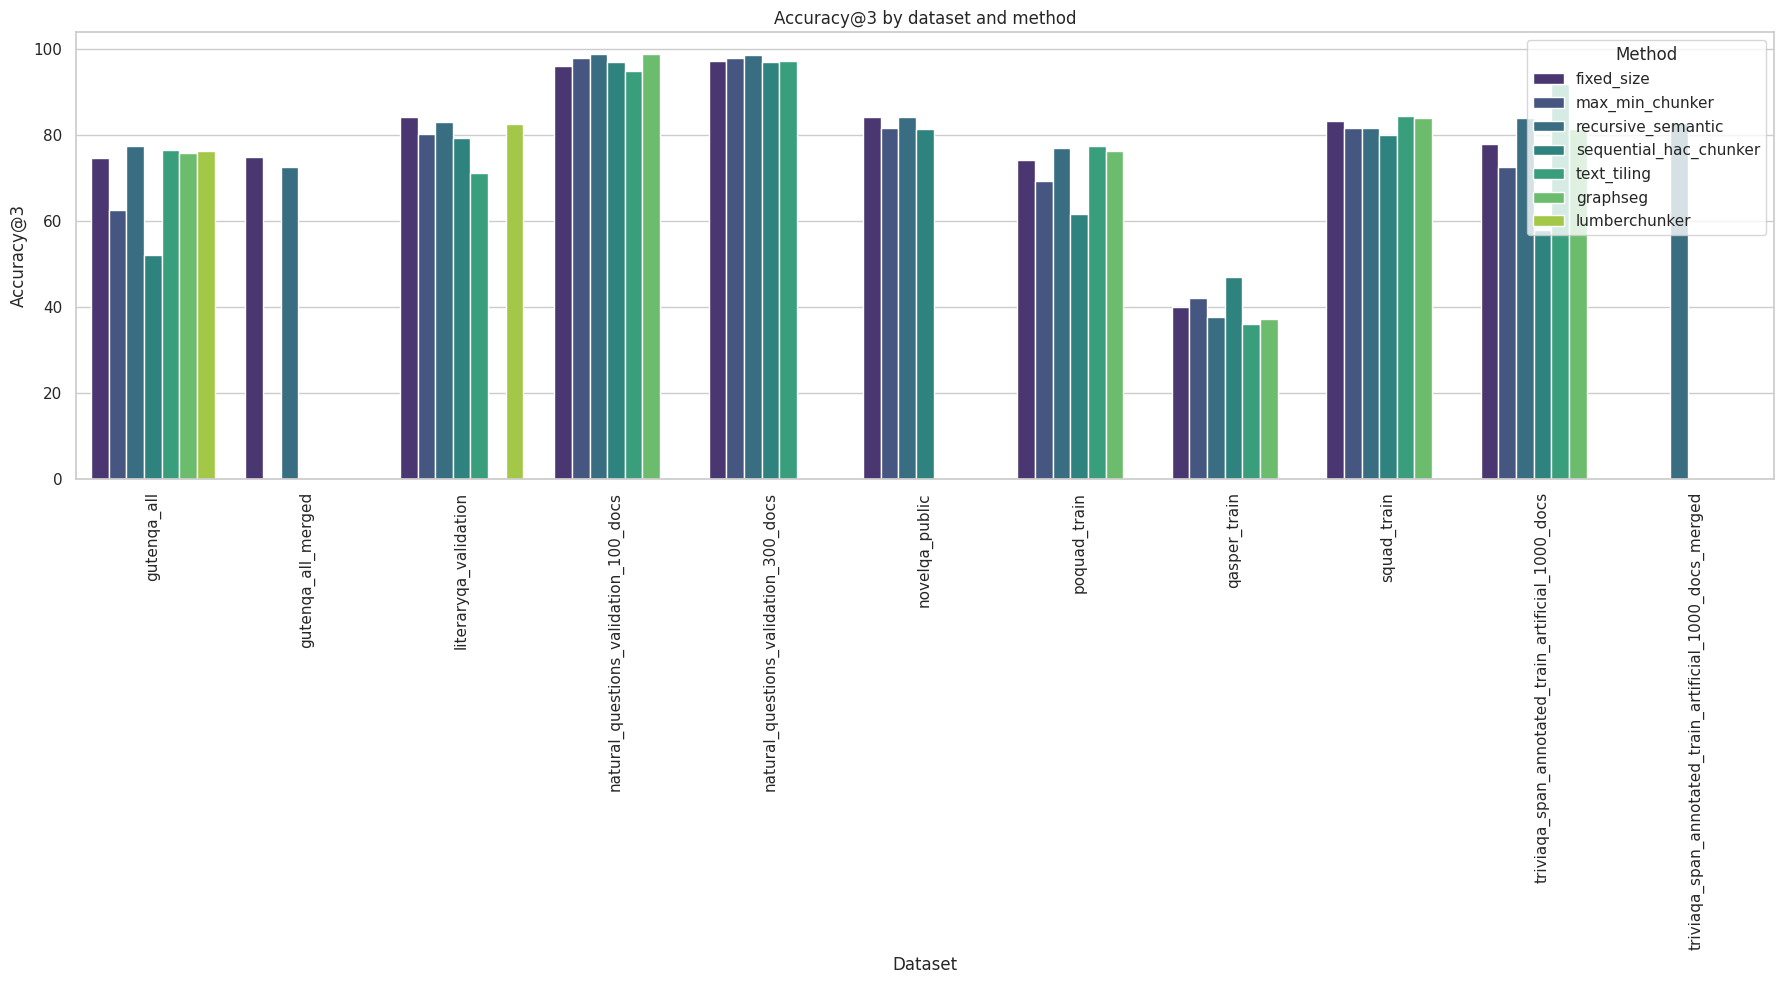

In [195]:
plot_metric_by_method('Accuracy@3')

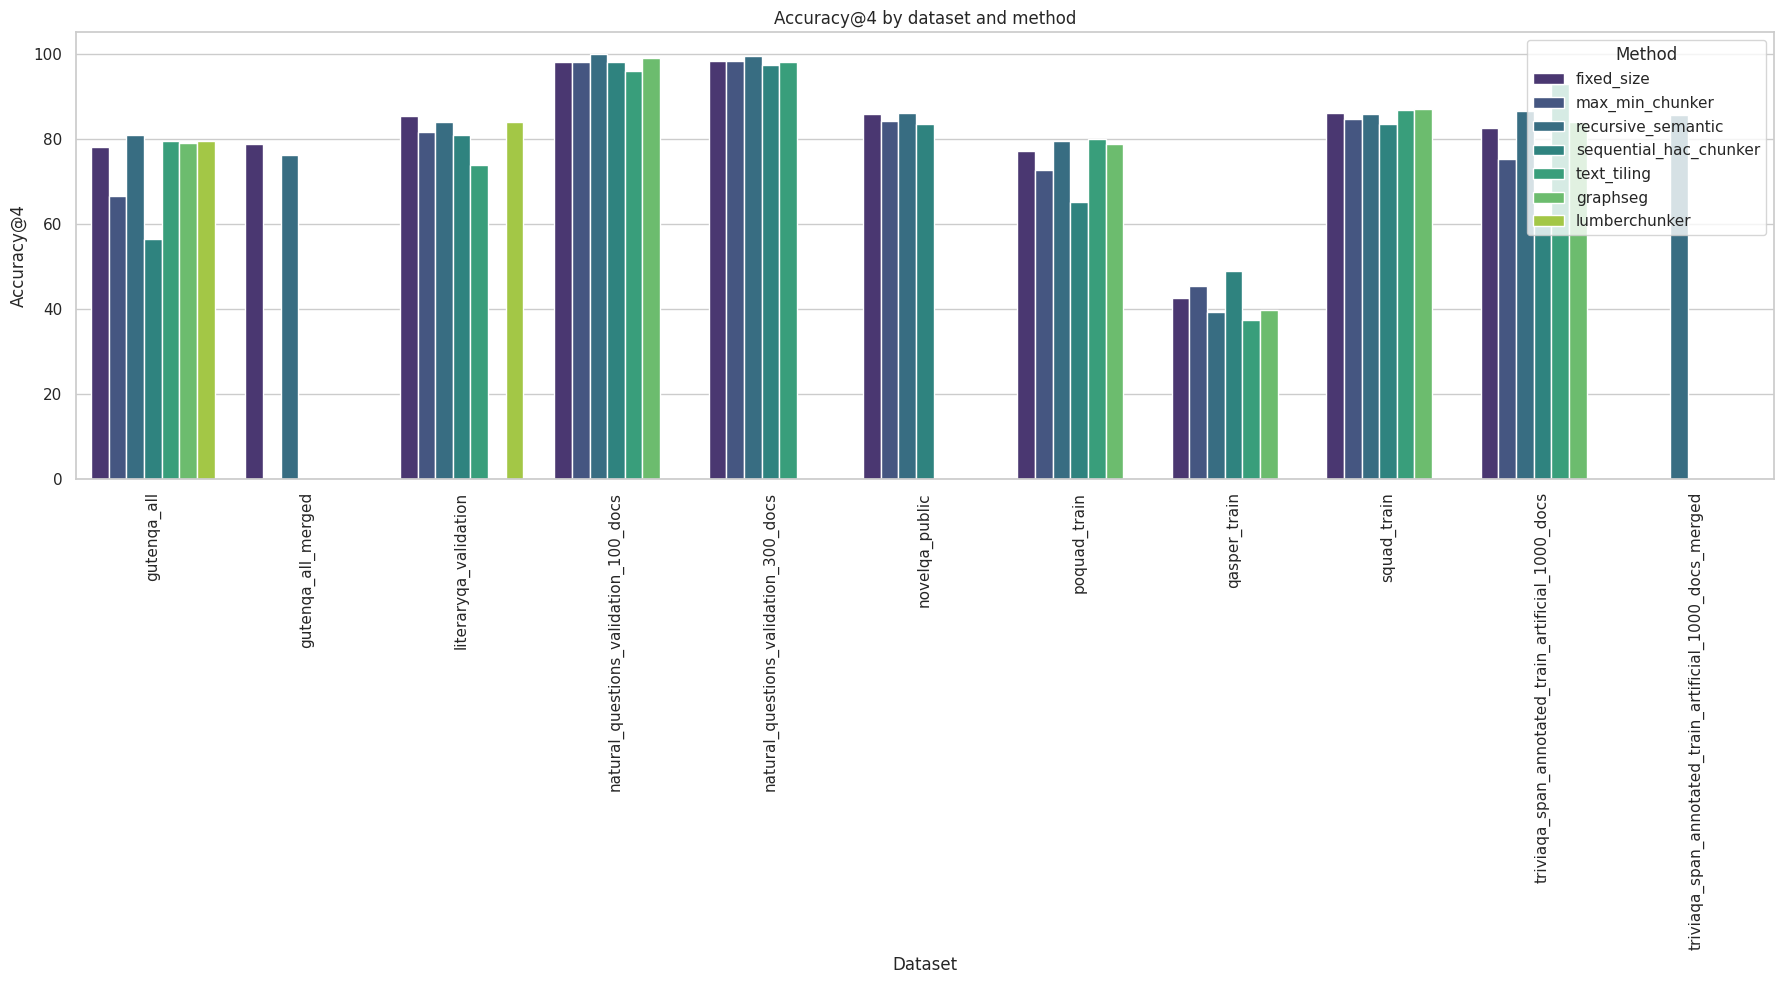

In [196]:
plot_metric_by_method('Accuracy@4')

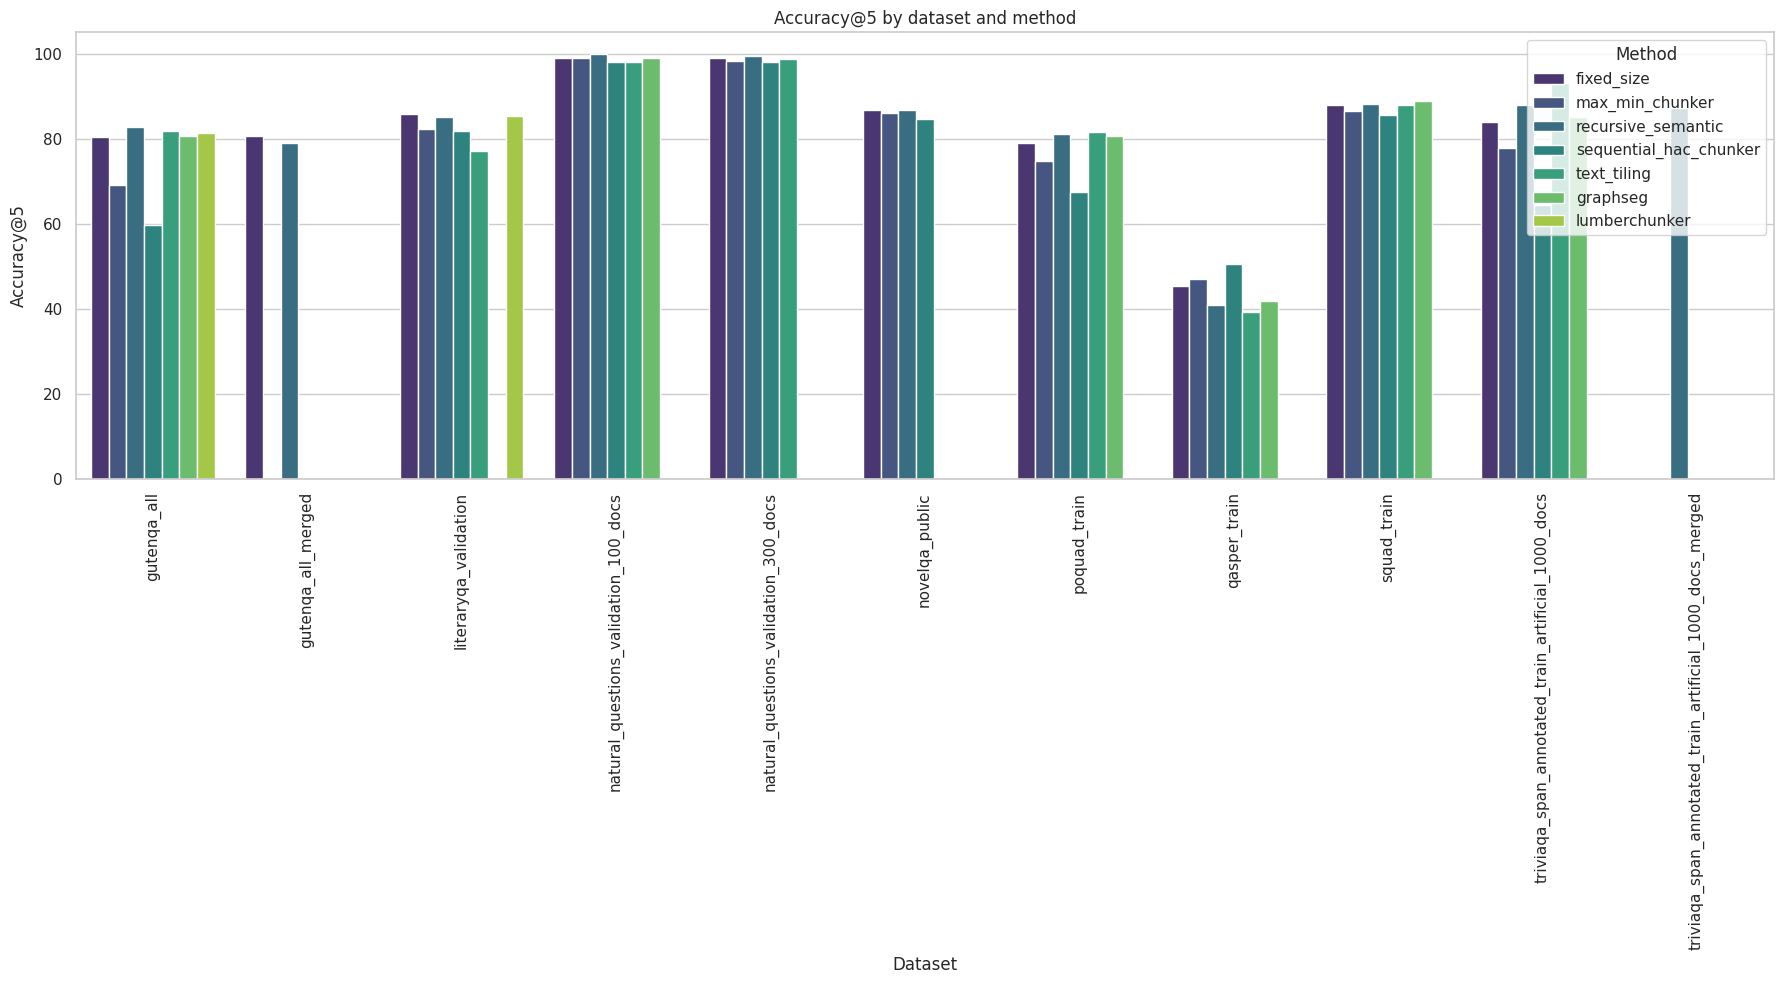

In [197]:
plot_metric_by_method('Accuracy@5')

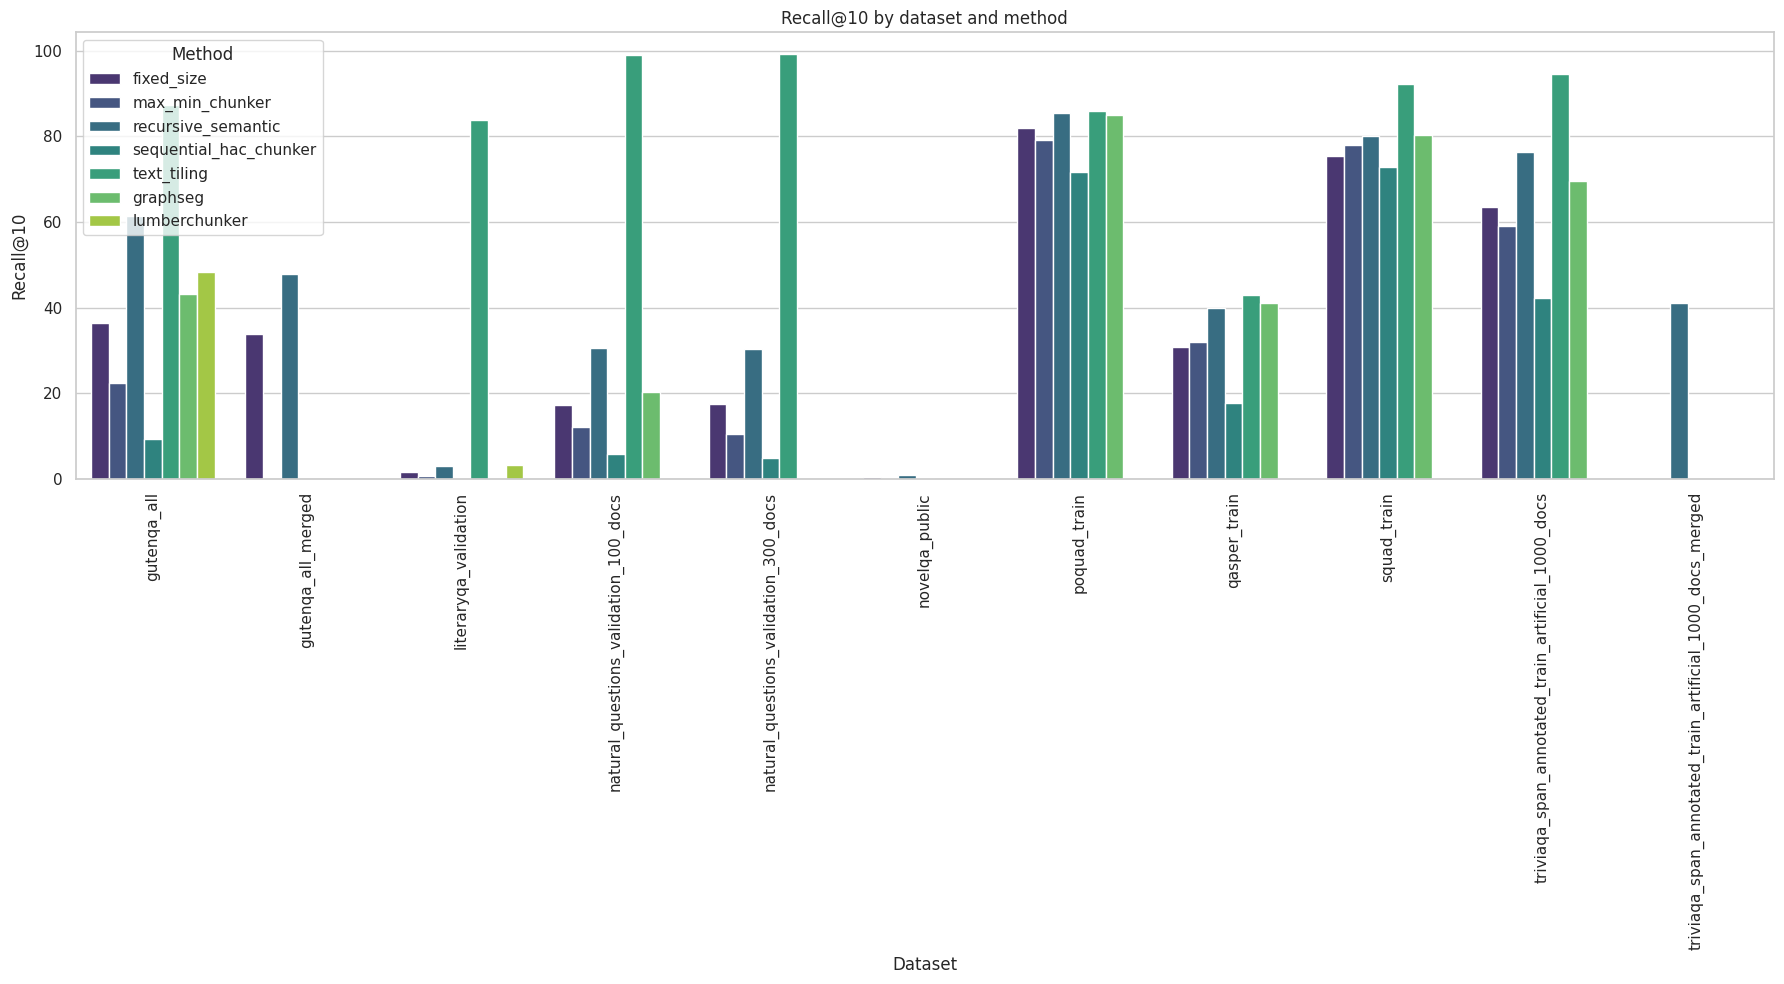

In [198]:
plot_metric_by_method('Recall@10')

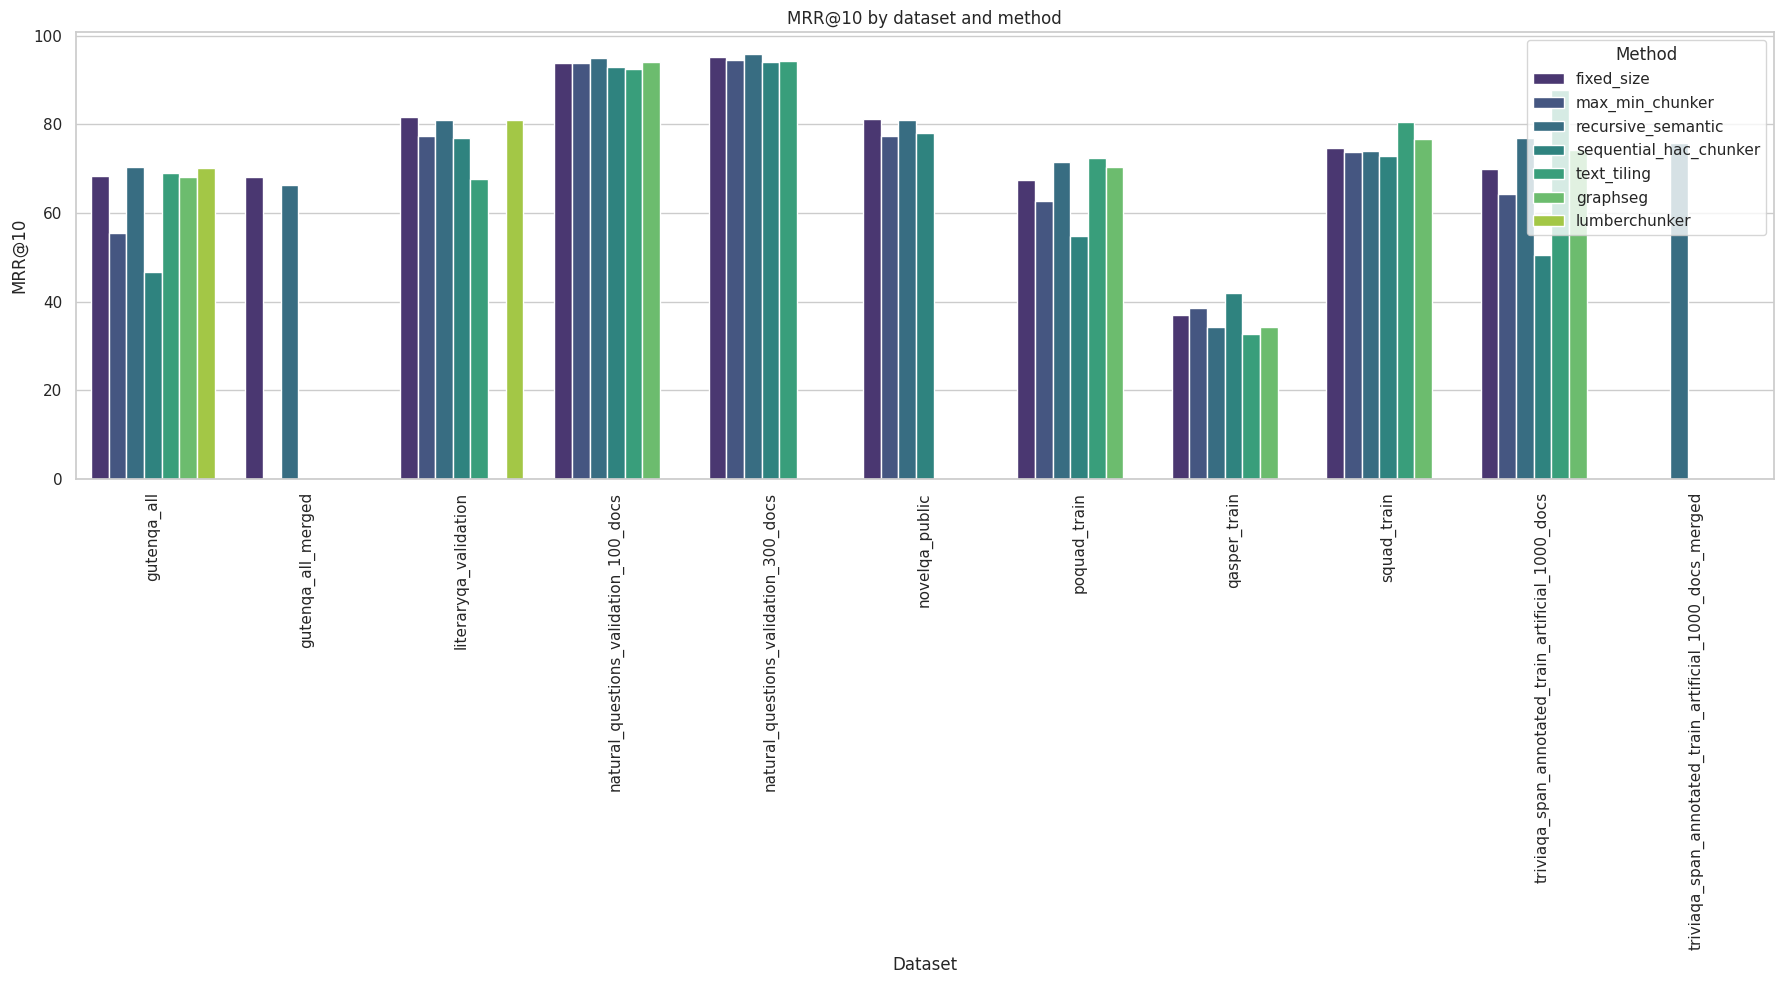

In [199]:
plot_metric_by_method('MRR@10')

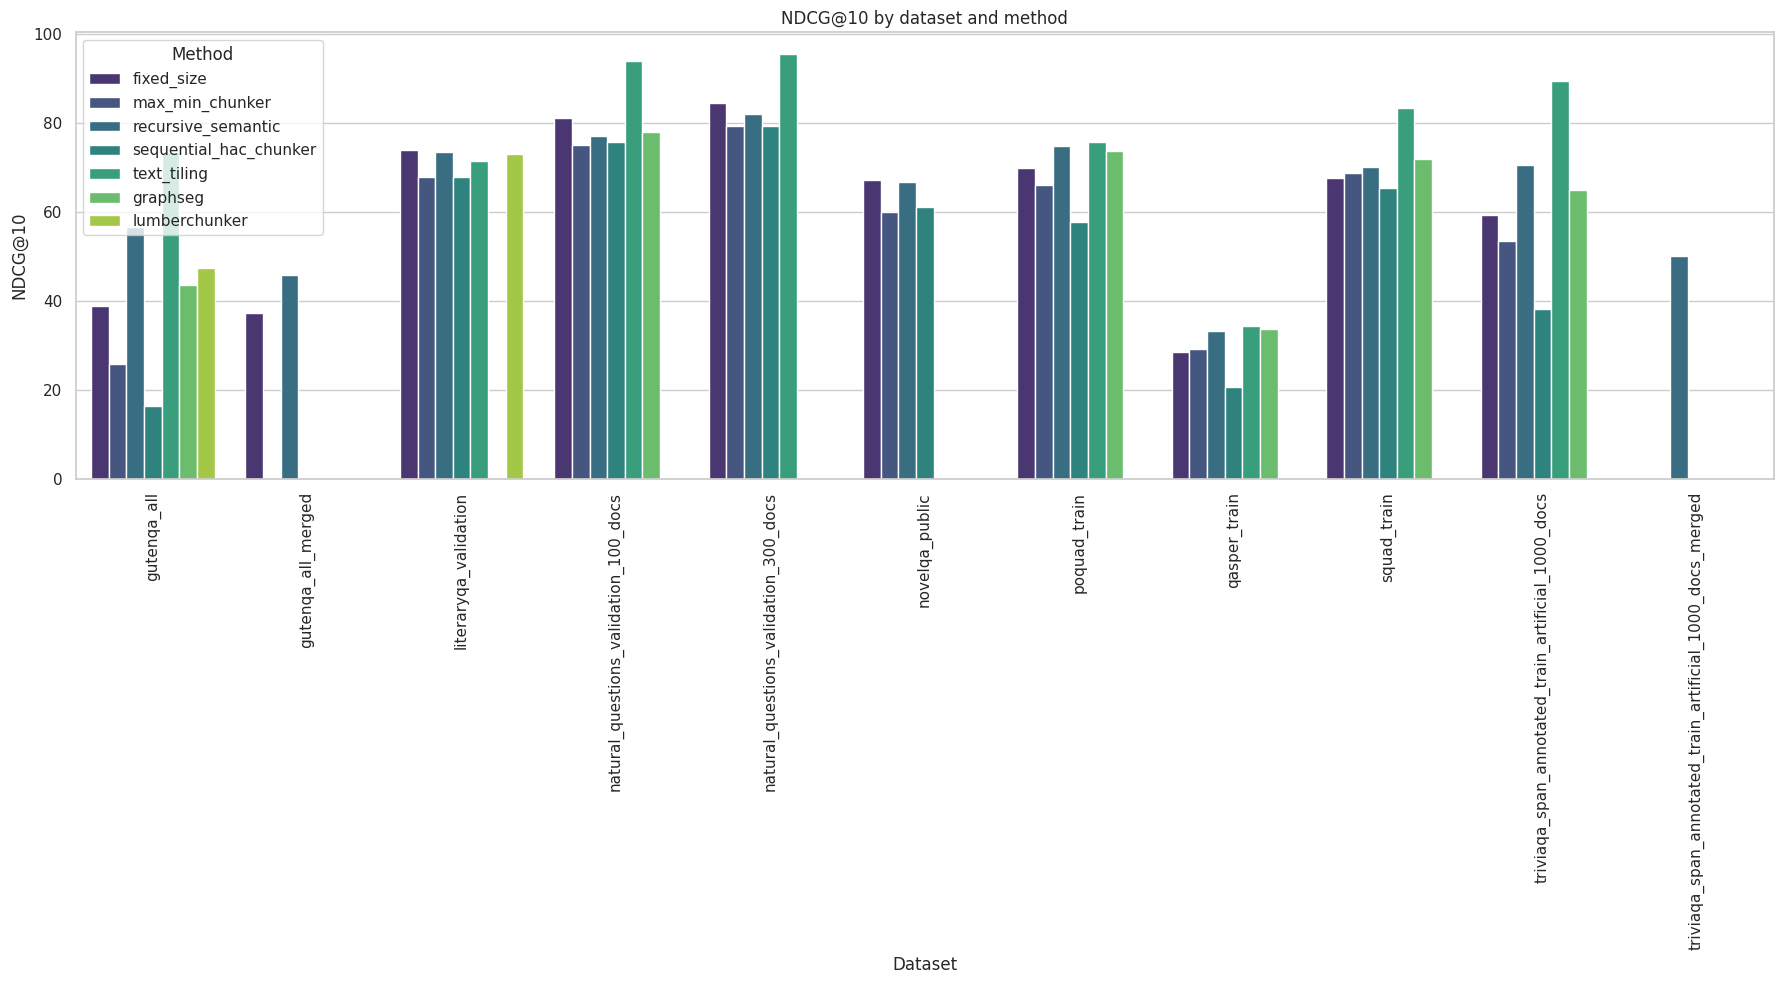

In [200]:
plot_metric_by_method('NDCG@10')

## Timing analysis

In [201]:
def plot_timings(timing):
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(
        data=merged,
        x='dataset',
        y=f"{timing}",
        hue='method',
        palette='viridis'
    )

    plt.xlabel('Dataset')
    plt.ylabel(timing)
    plt.title(f"{timing} by dataset and method")
    plt.xticks(rotation=90)

    # Format y-ticks: seconds + hours
    ticks = ax.get_yticks()
    ax.set_yticklabels([f"{int(t)} ({t/3600:.2f}h)" for t in ticks])

    plt.legend(title='Method')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_39563/1726576880.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t)} ({t/3600:.2f}h)" for t in ticks])


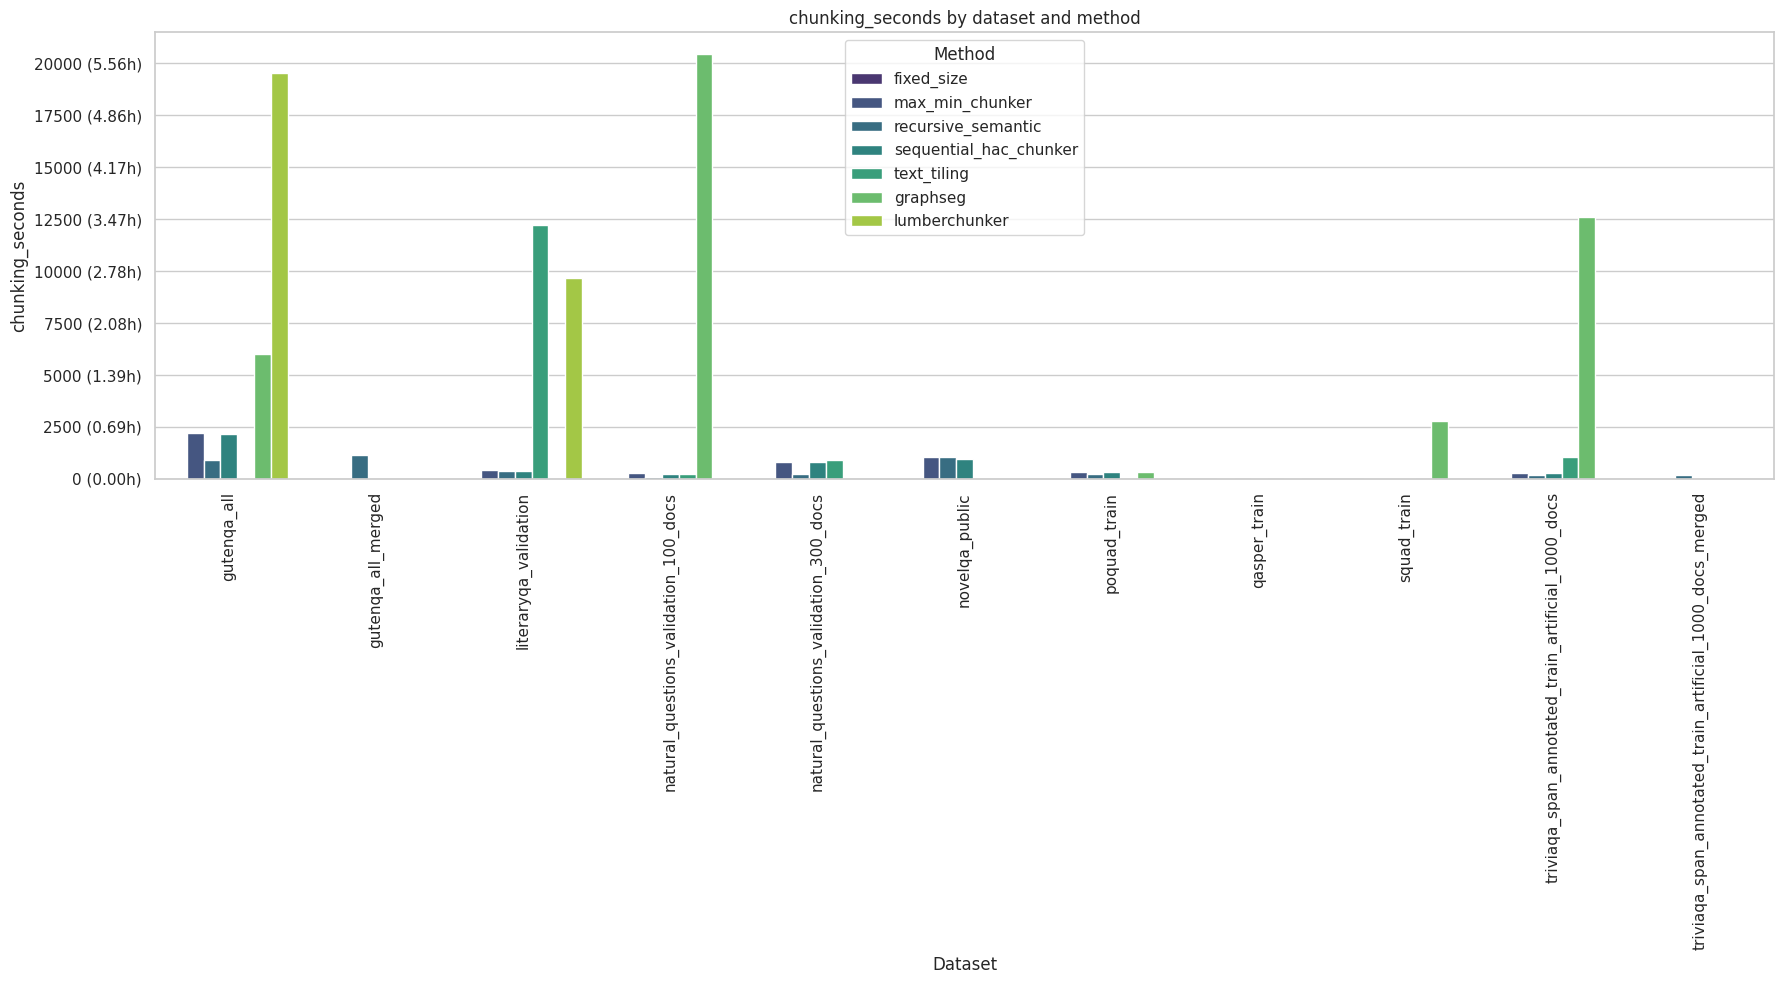

In [202]:
plot_timings('chunking_seconds')

/tmp/ipykernel_39563/1726576880.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t)} ({t/3600:.2f}h)" for t in ticks])


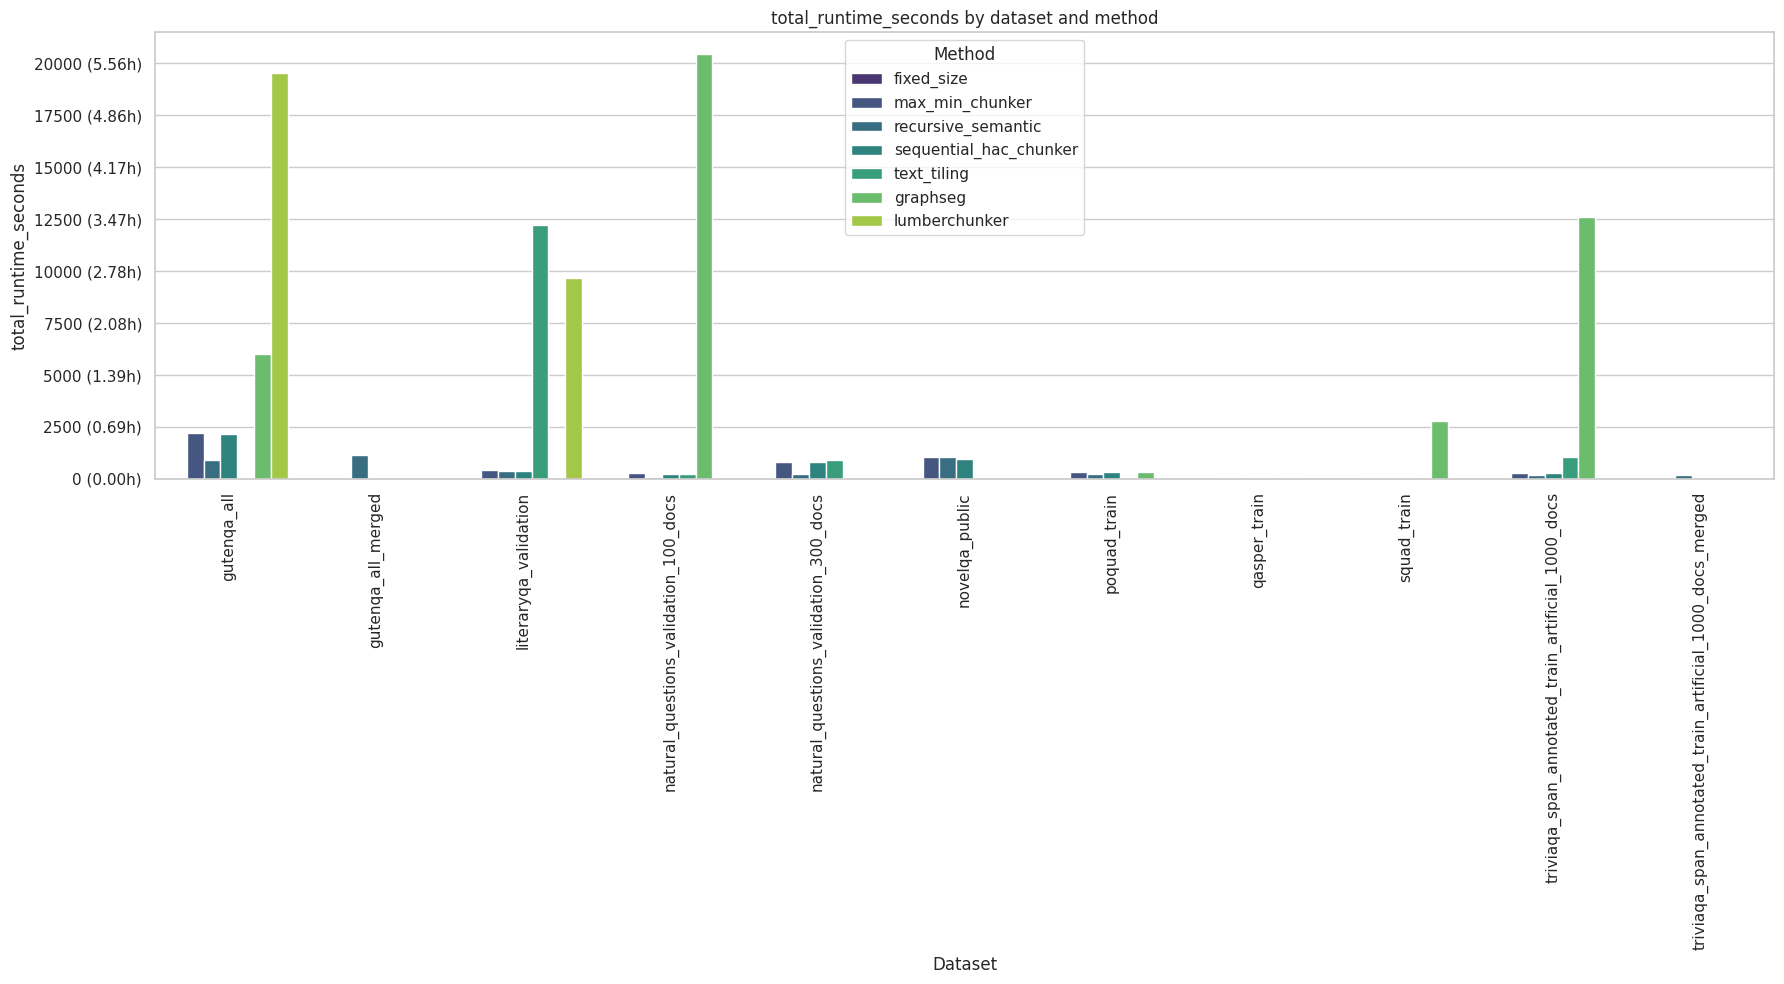

In [203]:
plot_timings('total_runtime_seconds')